# Задание 2

In [1]:
# Подключим нужные для базовых операций библиотеки
import seaborn as sb
from matplotlib import pyplot as plt
import numpy as np
import pandas as pd

# Подключим пакеты для использования OLS метода и тестов
import statsmodels.api as sm
from sklearn.linear_model import LinearRegression
from scipy import stats
from statsmodels.stats.outliers_influence import variance_inflation_factor 

# Подгрузим полезные функции
from my_utils import *

# Сделаем автоподгрузку всех изменений при перепрогонке ячейки
%load_ext autoreload
%autoreload 2

In [38]:
# Определим параметры выборки для задачи преобразования факторов
# Создадим удобный словарь, чтобы передавать его в функцию
dist_params = dict(

    # Зададим параметры распределения факторов
    x1_mean = 10,
    x1_std = 5,
    x2_mean = 20,
    x2_std = 2,
    x3_mean = -10,
    x3_std = 8,
    
    # Зададим параметры распределения ошибки
    e_mean = 0,
    e_std = 10,

    corr_12 = 0.0,
    corr_13 = 0.0,
    corr_23 = 0.8,

    # Укажем размер выборки
    N = 1000,

    # Зададим действительные параметры модели
    beta0 = 20,
    beta1 = 7,
    beta2 = 3,
    beta3 = -2
)

# Установим стартовую точку для алгоритма генерации случайных чисел
RANDOM_SEED = 42

In [36]:
def gen_data(params, seed):
    # np.random.seed(seed)
    
    means = [params['x1_mean'], params['x2_mean'], params['x3_mean']]

    # Вычислим наполнение матрицы ковариаций 
    var_1 = params['x1_std']**2
    var_2 = params['x2_std']**2
    var_3 = params['x3_std']**2

    cov_12 = params['corr_12'] * params['x1_std'] * params['x2_std']
    cov_23 = params['corr_23'] * params['x3_std'] * params['x2_std']
    cov_13 = params['corr_13'] * params['x1_std'] * params['x3_std']
    
    covs = [[var_1, cov_12, cov_13],
            [cov_12, var_2, cov_23],
            [cov_13, cov_23, var_3]]

    # Сгененрируем требующуюся выборку
    X = np.random.multivariate_normal(
        mean=means,
        cov=covs,
        size=params['N']
    )

    # А также сгененируем случайную ошибку как величину из нормального распределения
    e = np.random.normal(loc=params['e_mean'], scale=params['e_std'], size=params['N'])

    # Здесь мы создаем таргет 'y' как некую функцию от x1, x2 и ошибки e
    y = params['beta0'] \
        + params['beta1'] * X[:, 0] \
        + params['beta2'] * X[:, 1] \
        + params['beta3'] * X[:, 2] \
        + e

    # Для удобства сохраним вектора в pandas dataframe
    dataset = pd.DataFrame({'x1': X[:, 0], 'x2': X[:, 1], 'x3': X[:, 2], 'e': e, 'y': y})
    return dataset

In [25]:
dt_data = gen_data(params=dist_params, seed=RANDOM_SEED)

display(dt_data)

,x1,x2,x3,e,y
0,5.682532,20.047810,-9.929401,7.851851,127.773003
1,12.363152,22.218659,-7.031796,-17.776810,155.421229
2,-3.521958,21.503933,-9.113690,7.147456,67.005550
3,13.166634,20.846017,-10.931895,-2.337241,172.367250
4,5.075034,19.673038,-10.426975,7.074577,121.618931
...,...,...,...,...,...
995,7.224916,21.338284,-6.016667,22.098557,156.687826
996,9.887820,19.738021,-9.518114,3.269945,151.698747
997,14.811726,17.526285,-11.115678,-8.351245,167.909692
998,6.845772,20.078784,-8.948459,16.529131,144.685889


In [ ]:
num_covered_beta = [0, 0, 0]

N_iter = 10000

for _ in range(N_iter):
    dt_data = gen_data(params=dist_params, seed=RANDOM_SEED)
    dt_data, model = train_model(dt_data, target='y', feature_names=['x1', 'x2', 'x3'])
    coef_interval = model.conf_int()
    
    # Проверяем, что истинное беты попали интервал
    for i, beta_key in enumerate(['beta1', 'beta2', 'beta3'], start=0):
        num_covered_beta[i] += int(coef_interval.iloc[i+1, 0] <= dist_params[beta_key] <= coef_interval.iloc[i+1, 1])


In [ ]:
for i in range(3):
    print(f"Процент попаданий в доберительный интервал beta_{i+1}: {num_covered_beta[i]/N_iter}")

Процент попаданий в доберительный интервал beta_1: 0.9467
Процент попаданий в доберительный интервал beta_2: 0.9494
Процент попаданий в доберительный интервал beta_3: 0.9498


Как мы можем увидет, что все истинные беты попадают в доверительный интервал примерно 95% вероятностью при уровни значимости оценок 5%. 

# Задание 3

In [41]:
# Подгрудаем датасет
heart_deaseases_dt = pd.read_csv('heart_disease_health_indicators_BRFSS2015.csv')
display(heart_deaseases_dt)

,HeartDiseaseorAttack,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,Diabetes,PhysActivity,Fruits,...,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
0,0.0,1.0,1.0,1.0,40.0,1.0,0.0,0.0,0.0,0.0,...,1.0,0.0,5.0,18.0,15.0,1.0,0.0,9.0,4.0,3.0
1,0.0,0.0,0.0,0.0,25.0,1.0,0.0,0.0,1.0,0.0,...,0.0,1.0,3.0,0.0,0.0,0.0,0.0,7.0,6.0,1.0
2,0.0,1.0,1.0,1.0,28.0,0.0,0.0,0.0,0.0,1.0,...,1.0,1.0,5.0,30.0,30.0,1.0,0.0,9.0,4.0,8.0
3,0.0,1.0,0.0,1.0,27.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,0.0,0.0,0.0,0.0,11.0,3.0,6.0
4,0.0,1.0,1.0,1.0,24.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,3.0,0.0,0.0,0.0,11.0,5.0,4.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
253675,0.0,1.0,1.0,1.0,45.0,0.0,0.0,0.0,0.0,1.0,...,1.0,0.0,3.0,0.0,5.0,0.0,1.0,5.0,6.0,7.0
253676,0.0,1.0,1.0,1.0,18.0,0.0,0.0,2.0,0.0,0.0,...,1.0,0.0,4.0,0.0,0.0,1.0,0.0,11.0,2.0,4.0
253677,0.0,0.0,0.0,1.0,28.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,1.0,0.0,0.0,0.0,0.0,2.0,5.0,2.0
253678,0.0,1.0,0.0,1.0,23.0,0.0,0.0,0.0,0.0,1.0,...,1.0,0.0,3.0,0.0,0.0,0.0,1.0,7.0,5.0,1.0


c:\Users\krasn\source\repos\SHAD_MTS_24_25\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(



 ================================================== TRAIN RESULTS ================================================== 

ROC AUC score: 0.841

              precision    recall  f1-score   support

         0.0       0.97      0.74      0.84    229787
         1.0       0.24      0.80      0.37     23893

    accuracy                           0.74    253680
   macro avg       0.61      0.77      0.60    253680
weighted avg       0.90      0.74      0.79    253680



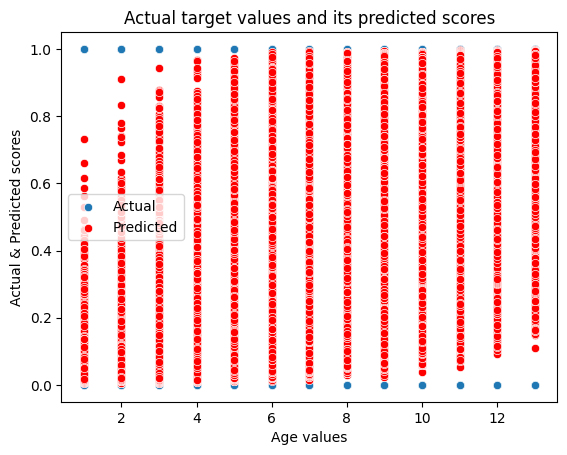

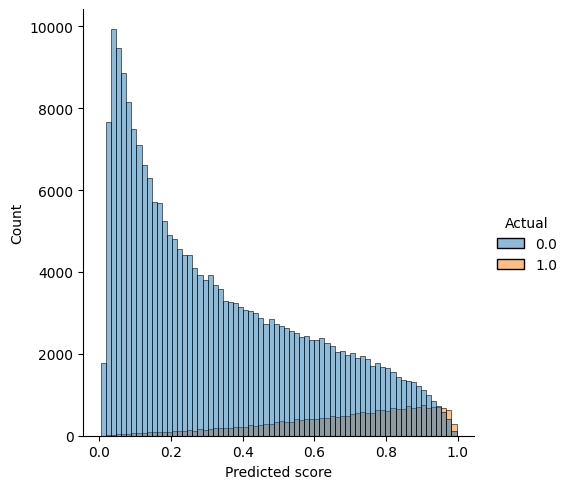

Predicted,0.000000,1.000000
Actual,,
0.000000,169266,60521
1.000000,4897,18996


In [50]:

# Обучим Logit модель на первых 5 колонках + Age
dt_logit, model_logit = train_binary(
    heart_deaseases_dt, target='HeartDiseaseorAttack',
    plot_feature='Age',
    feature_names=heart_deaseases_dt.columns[1:].to_list(),
    model_type='logit', pkg='sklearn', class_weight='balanced')

## Выводы по результатам модели

### 1️. Precision и Recall  
- **Точность (Precision)**  
  - Для здоровых (класс 0): **97%** → почти все предсказанные "здоровые" действительно не имеют болезни.  
  - Для больных (класс 1): **24%** → только 24% предсказанных "больных" действительно больны.  

- **Полнота (Recall)**  
  - Для здоровых: **74%** → модель правильно определяет 74% здоровых пациентов.  
  - Для больных: **80%** → модель выявляет 80% больных, но 20% остаются незамеченными.  

### 2️. Метрики F1-macro и ROC-AUC  
- **F1-macro (0.60)**  
  - Средний баланс между точностью и полнотой, показывает слабость модели в распознавании больных.  

- **ROC-AUC (0.841)**  
  - Высокое значение → модель хорошо разделяет классы, но текущий порог предсказаний (0.5) даёт перекос.  


### 3️. Прогноз на 100 пациентов в месяц  
Допустим, к врачу приходят 100 человек.  

- **75 пациентов получат верный диагноз**, из них:  
  - 67 здоровых правильно распознаны.  
  - 8 больных правильно диагностированы.  

- **Ошибки:**  
  - **23 здоровых** ошибочно получат диагноз "болен".  
  - **2 больных** останутся незамеченными.  


### 4️. Пригодность для практического использования  
**Проблемы:**  
 - **Проблема ложноположительных (FP):** 23% ошибочных диагнозов среди здоровых — это много, но в медицине лучше перестраховаться, чем пропустить болезнь.
 - **Проблема ложноотрицательных (FN):** 20% больных остаются незамеченными — это может быть критично. Лучше вообще не пропускать больных.


